# Crime Data Analysis Project
# Author: Mohamed Salah

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'


import warnings
warnings.filterwarnings("ignore")

sns.set_style('darkgrid')
sns.set_palette('muted')

# Step 1: Data Cleaning

In [31]:
df = pd.read_csv('https://raw.githubusercontent.com/MSalah-Data/Python-Projects/refs/heads/main/Crime%20Analysis%20Project/crimes_sample.csv')
df.head(5)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION,HOUR
0,231307184,2023-03-03,2023-03-03,100,Newton,THEFT OF IDENTITY,22.0,F,B,Unknown,Invest Cont,2700 S GRAND AV,1
1,221321139,2022-11-18,2022-11-18,1030,Newton,INTIMATE PARTNER - SIMPLE ASSAULT,41.0,F,H,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Adult Arrest,600 E 43RD PL,10
2,220124178,2022-11-09,2022-11-09,1300,Central,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",26.0,M,B,OTHER CUTTING INSTRUMENT,Invest Cont,700 S MAIN ST,13
3,221116610,2022-11-22,2022-11-14,2200,Northeast,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,70.0,M,F,Unknown,Invest Cont,1900 KEMPER ST,22
4,221114466,2022-09-29,2022-09-28,2330,Northeast,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),49.0,F,H,Unknown,Invest Cont,1400 LOGAN ST,23


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DR_NO         20000 non-null  int64  
 1   Date Rptd     20000 non-null  object 
 2   DATE OCC      20000 non-null  object 
 3   TIME OCC      20000 non-null  int64  
 4   AREA NAME     20000 non-null  object 
 5   Crm Cd Desc   20000 non-null  object 
 6   Vict Age      20000 non-null  float64
 7   Vict Sex      20000 non-null  object 
 8   Vict Descent  20000 non-null  object 
 9   Weapon Desc   20000 non-null  object 
 10  Status Desc   20000 non-null  object 
 11  LOCATION      20000 non-null  object 
 12  HOUR          20000 non-null  int64  
dtypes: float64(1), int64(3), object(9)
memory usage: 2.0+ MB


In [33]:
df.describe()

,DR_NO,TIME OCC,Vict Age,HOUR
count,2.000000e+04,20000.000000,20000.000000,20000.000000
mean,2.255875e+08,1303.756300,39.932550,12.851250
std,5.016675e+06,655.019673,15.426072,6.542527
min,2.201008e+08,1.000000,2.000000,0.000000
25%,2.210109e+08,835.000000,28.000000,8.000000
50%,2.220124e+08,1341.500000,37.000000,13.000000
75%,2.310042e+08,1830.000000,50.000000,18.000000
max,2.321112e+08,2359.000000,99.000000,23.000000


In [34]:
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   DR_NO         20000 non-null  int64         
 1   Date Rptd     20000 non-null  datetime64[ns]
 2   DATE OCC      20000 non-null  datetime64[ns]
 3   TIME OCC      20000 non-null  int64         
 4   AREA NAME     20000 non-null  object        
 5   Crm Cd Desc   20000 non-null  object        
 6   Vict Age      20000 non-null  float64       
 7   Vict Sex      20000 non-null  object        
 8   Vict Descent  20000 non-null  object        
 9   Weapon Desc   20000 non-null  object        
 10  Status Desc   20000 non-null  object        
 11  LOCATION      20000 non-null  object        
 12  HOUR          20000 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(3), object(7)
memory usage: 2.0+ MB


In [35]:
df['Weapon Desc'] = df['Weapon Desc'].fillna("Unknown")

In [36]:
df.loc[df['Vict Age'] <= 0, 'Vict Age'] = None
df = df.dropna(subset=['Vict Age'])
df.shape

(20000, 13)

# Step 2: Feature Engineering

In [37]:
crime_counts = df['Crm Cd Desc'].value_counts()

crime_counts.head(10)

,count
Crm Cd Desc,
THEFT OF IDENTITY,2429
BATTERY - SIMPLE ASSAULT,2116
BURGLARY FROM VEHICLE,1498
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1420
INTIMATE PARTNER - SIMPLE ASSAULT,1315
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER),1302
THEFT PLAIN - PETTY ($950 & UNDER),1183
"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)",1152
BURGLARY,1120


#Peak Crime Hour

In [38]:
df['HOUR'] = df['TIME OCC'] // 100
peak_crime_hour = df['HOUR'].value_counts().idxmax()

print(peak_crime_hour)

12


Peak Crime Hour = 12

#Night Crime Geography

In [39]:
night_df = df[(df['HOUR'] >= 22) | (df['HOUR'] <= 3)]
night_area = night_df['AREA NAME'].value_counts().idxmax()

print(night_area)

Central


"Central area experiences the highest crime frequency during night hours (10 PM – 4 AM)."

#Victim Demographics

In [40]:
bins = [0, 17, 25, 34, 44, 54, 64, 100]
labels = ["0-17", "18-25", "26-34", "35-44", "45-54", "55-64", "65+"]
victim_ages = pd.cut(df['Vict Age'], bins=bins, labels=labels)
victim_ages = victim_ages.value_counts().sort_index()

print(victim_ages)

Vict Age
0-17      463
18-25    3110
26-34    5071
35-44    4641
45-54    3008
55-64    2126
65+      1581
Name: count, dtype: int64


In [41]:
Q1 = df['Vict Age'].quantile(0.25)
Q3 = df['Vict Age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_age = df[(df['Vict Age'] < lower_bound) | (df['Vict Age'] > upper_bound)]

print("Outliers in Age:", outliers_age.shape[0])

Outliers in Age: 132


"A noticeable number of age outliers suggests the presence of both very young and older victims, indicating crimes affect a wide demographic range."

In [42]:
Q1_t = df['TIME OCC'].quantile(0.25)
Q3_t = df['TIME OCC'].quantile(0.75)

IQR_t = Q3_t - Q1_t

lower_t = Q1_t - 1.5 * IQR_t
upper_t = Q3_t + 1.5 * IQR_t

outliers_time = df[(df['TIME OCC'] < lower_t) | (df['TIME OCC'] > upper_t)]

print("Outliers in Time:", outliers_time.shape[0])

Outliers in Time: 0


# Step 3: Analysis

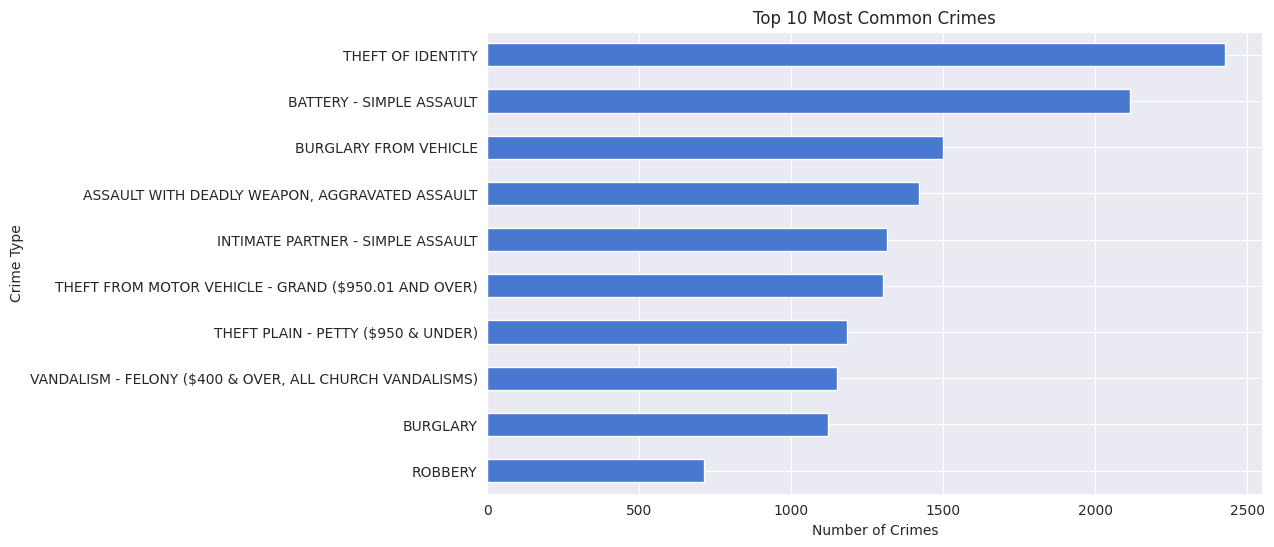

In [43]:

top_crimes = df['Crm Cd Desc'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_crimes.plot(kind='barh')

plt.title("Top 10 Most Common Crimes")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")

plt.gca().invert_yaxis()
plt.show()

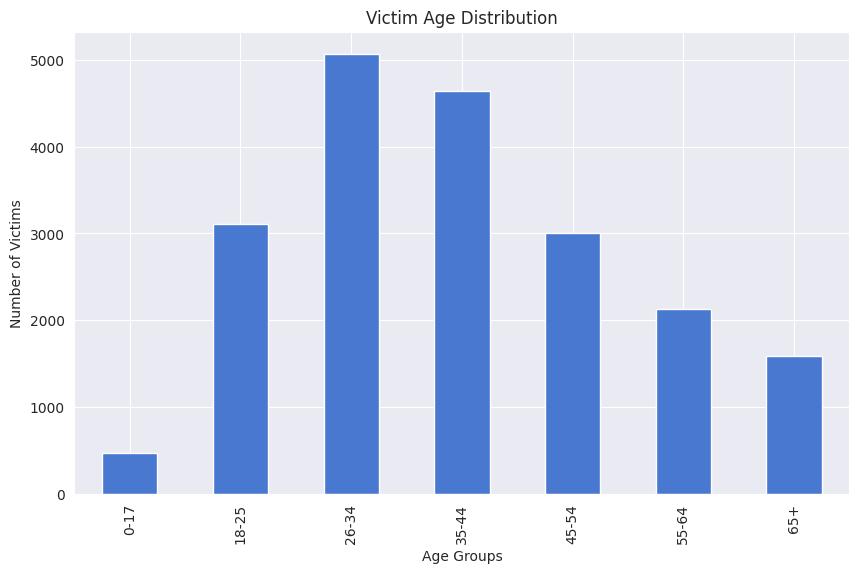

In [46]:
plt.figure(figsize=(10,6))
victim_ages.plot(kind='bar')

plt.title("Victim Age Distribution")
plt.xlabel("Age Groups")
plt.ylabel("Number of Victims")

plt.show()

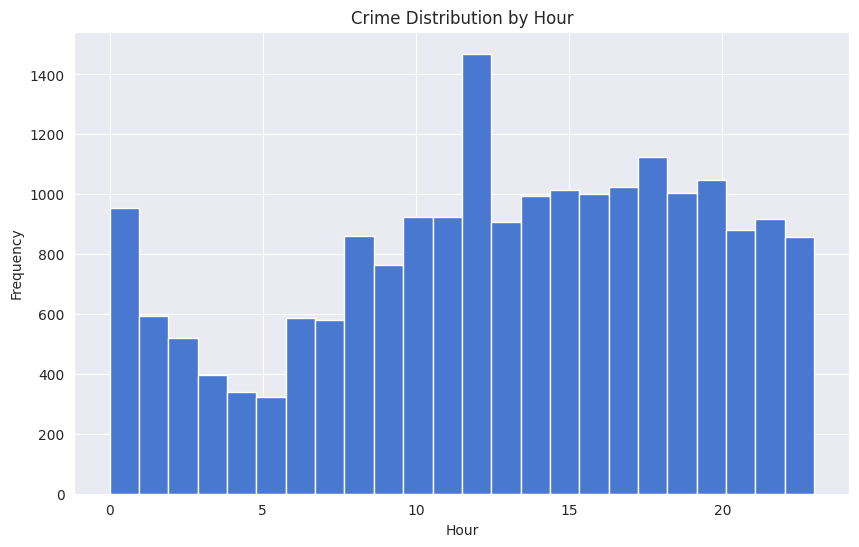

In [47]:
plt.figure(figsize=(10,6))
df['HOUR'].plot(kind='hist', bins=24)

plt.title("Crime Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Frequency")

plt.show()